In [1]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew

#scipy chi
from scipy.stats import chi,chi2_contingency,chi2
import math
import matplotlib.pyplot as plt
import seaborn as sns

import os
import sys
from copy import deepcopy


# =====================================
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,\
                                  getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                  get_variance_inflation_factors,goodnessOfFitTestOfParams



#### Box-Cox On Dependent Variable i.e y

**Qus: where to use?**

perform a Box-Cox power transformation, which helps convert non-normal data into a more normally distributed shape—especially useful when **dealing with heteroskedasticity** or skewed distributions.


Skewness: 0.981339
Actual Kurtosis with fisher=Fals: 3.897522
excess  Kurtosis: 0.897522


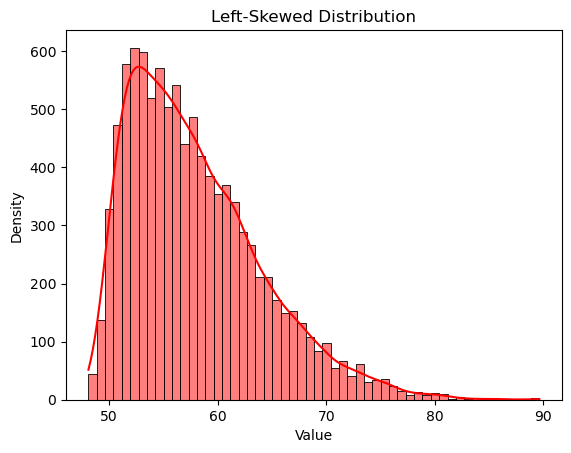

In [2]:
# Parameters
size = 10000         # Number of data points
skewness = 10       # Negative = left skew
loc = 50            # Center of distribution
scale = 10          # Spread

# Generate data
X = skewnorm.rvs(a=skewness, loc=loc, scale=scale, size=size)
print("Skewness:", round(skew(X),6))
print("Actual Kurtosis with fisher=Fals:", round(kurtosis(X, fisher=False),6))
print("excess  Kurtosis:", round(kurtosis(X),6))  # excess kurtosis


# Plot histogram
sns.histplot(x=X,kde=True,color='red', edgecolor='black')
#plt.hist(data, bins=30, color='skyblue', edgecolor='black', density=True)
plt.title("Left-Skewed Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()


In [3]:
transformed_data, best_lambda = boxcox(X)
print("Optimal λ:", best_lambda)
print(f"Transformed data: {transformed_data.shape}")
print("Skewness:", round(skew(transformed_data),6))
print("Actual Kurtosis with fisher=Fals:", round(kurtosis(transformed_data, fisher=False),6))
print("excess  Kurtosis:", round(kurtosis(transformed_data),6))  # excess kurtosis

Optimal λ: -3.0297245537901043
Transformed data: (10000,)
Skewness: 0.083926
Actual Kurtosis with fisher=Fals: 2.203668
excess  Kurtosis: -0.796332


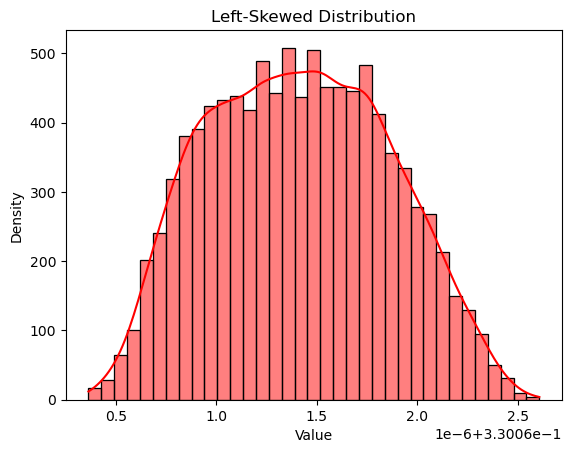

In [4]:
# Plot histogram
sns.histplot(x=transformed_data,kde=True,color='red', edgecolor='black')
#plt.hist(data, bins=30, color='skyblue', edgecolor='black', density=True)
plt.title("Left-Skewed Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()


#### Box-Cox On InDependent Variable i.e X